In [59]:
from Utils import concatenate_df, apply_distance_metric, predictions
from rashomon_set_definition import get_rashomon, rashomon_ratio, rr_variation, plot_rashomon_curve
from criteria_construction import preprocess_data, get_pca_metrics
from multi_dimensional_assessment import plot_relations, plot_variables_distributions
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, KBinsDiscretizer
import numpy as np
import pandas as pd
from joblib import load, Parallel, delayed
import duckdb
import equivalence_analysis as eqv 

## Macro-metrics computation

In [60]:
full_df = duckdb.query("""SELECT *
                          FROM read_parquet('/home/forru/Results/compass/model_results/**/*.parquet',
                          union_by_name = True)""").to_df()

baselines = duckdb.query("""SELECT *
                          FROM read_parquet('/home/forru/Results/compass/baseline/*.parquet',
                          union_by_name = True)""").to_df()



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [61]:
#preprocessing
cols_to_keep = [col for col in full_df.columns if col.startswith('val_') or col in ['model_id', 'model_type', 'n_neighbors']]
df = preprocess_data(full_df[cols_to_keep])

rtc_df = df[df['model_type'] == 'RuleTreeClassifier'].dropna(axis = 1)
knn_df = df[df['model_type'] == 'knn'].dropna(axis = 1)
lr_df = df[df['model_type'] == 'lr'].dropna(axis = 1)

df_pca = get_pca_metrics(df)
rtc_pca = df_pca[df_pca['model_type'] == 'RuleTreeClassifier']
knn_pca = df_pca[df_pca['model_type'] == 'knn']
lr_pca = df_pca[df_pca['model_type'] == 'lr']



## Multi-dimensional assessment

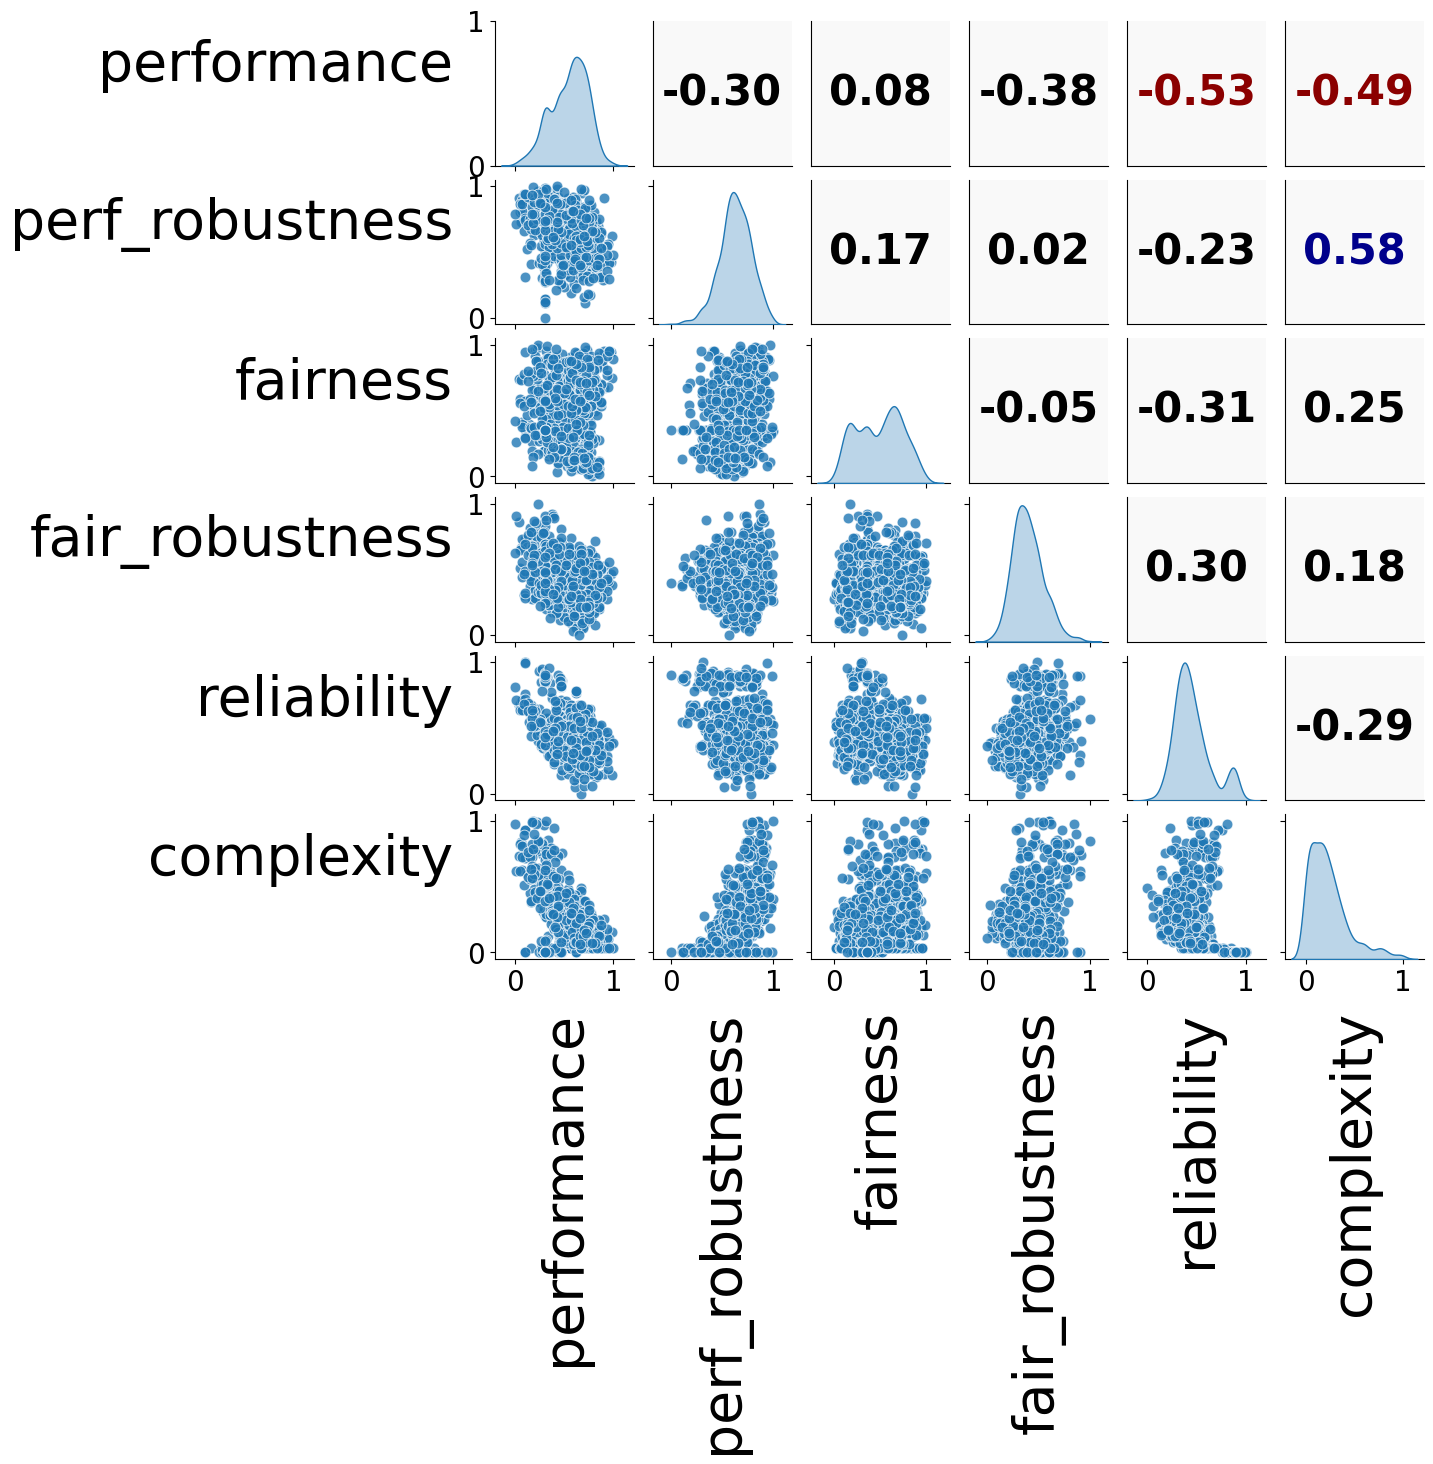

In [62]:
metrics_to_plot = ['performance','perf_robustness','fairness','fair_robustness', 'reliability', 'complexity']
plot_relations(rtc_pca, scale = True, save = False, metrics_to_plot = metrics_to_plot, figsize = (10,10), show_xlab=True,
               file_path = '/home/forru/Results/compass/plots', figname = 'Metrics Relations (DT)')

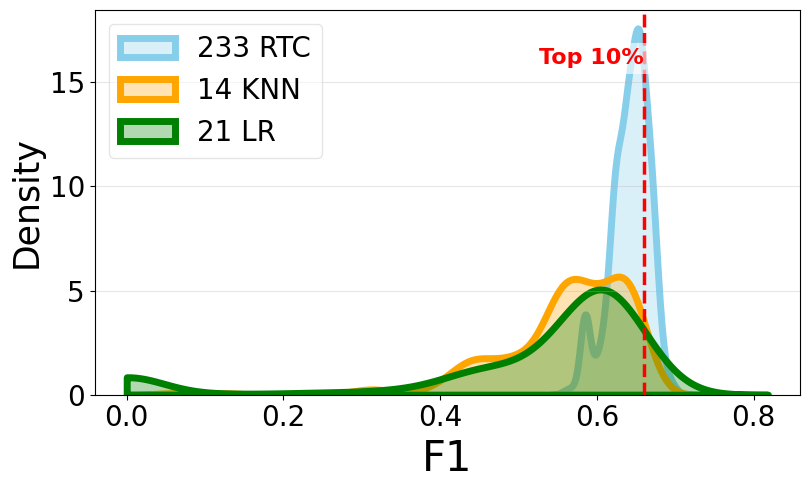

In [63]:
perf_config_metrics = ['val_f1']
fair_config_metrics = [   
    'val_dem_parity_inverted', 'val_equalized_odds_inverted', 'val_equal_opportunity_inverted', 'val_predictive_equality_inverted',
    'val_predictive_parity_inverted', 'val_neg_predictive_parity_inverted', 'val_cuae_inverted']
rob_config_metrics = [
    'val_acc_robustness', 'val_f1_robustness', 'val_precision_robustness', 'val_recall_robustness', 'val_equal_opp_robustness',
    'val_predictive_eq_robustness', 'val_pred_parity_robustness', 'val_eq_odds_robustness',  'val_dem_parity_robustness',
    'val_neg_pred_parity_robustness']
rel_config_metrics = ['val_expected_calibration_error_inverted', 'val_cat_cross_entropy_on_gt_inverted', 'val_mean_confidence_on_gt']

config_metrics = ['performance', 'perf_robustness']
scaler = MinMaxScaler().set_output(transform = 'pandas')
pca1=scaler.fit_transform(rtc_pca[config_metrics])
pca2=scaler.fit_transform(knn_pca[config_metrics])
pca3=scaler.fit_transform(lr_pca[config_metrics])
dataframes = [rtc_df, knn_df, lr_df]
plot_variables_distributions(dataframes, perf_config_metrics, percentile = 90, #xmin = 0.5,
                             save = False, file_path = '/home/forru/Results/compass/plots')

## Rashomon Set Study and Definition

In [64]:
base_thr = baselines['val_f1'].mean()
epsilons = [0.01, 0.05, 0.1]
thresholds = [base_thr - (eps*base_thr) for eps in epsilons]
conds = [f'val_f1 >= {thr}' for thr in thresholds]

all_data = [
    {'fam': 'DT','metric': np.sort(rtc_df['val_f1'].values), 'rs_models': {eps:get_rashomon(rtc_df, cond)[0].shape[0] for eps,cond in zip(epsilons, conds)}},
    {'fam': 'K-NN','metric': np.sort(knn_df['val_f1'].values), 'rs_models': {eps:get_rashomon(knn_df, cond)[0].shape[0] for eps,cond in zip(epsilons, conds)}},
    {'fam': 'LR','metric': np.sort(lr_df['val_f1'].values), 'rs_models': {eps:get_rashomon(lr_df, cond)[0].shape[0] for eps,cond in zip(epsilons, conds)}}
]


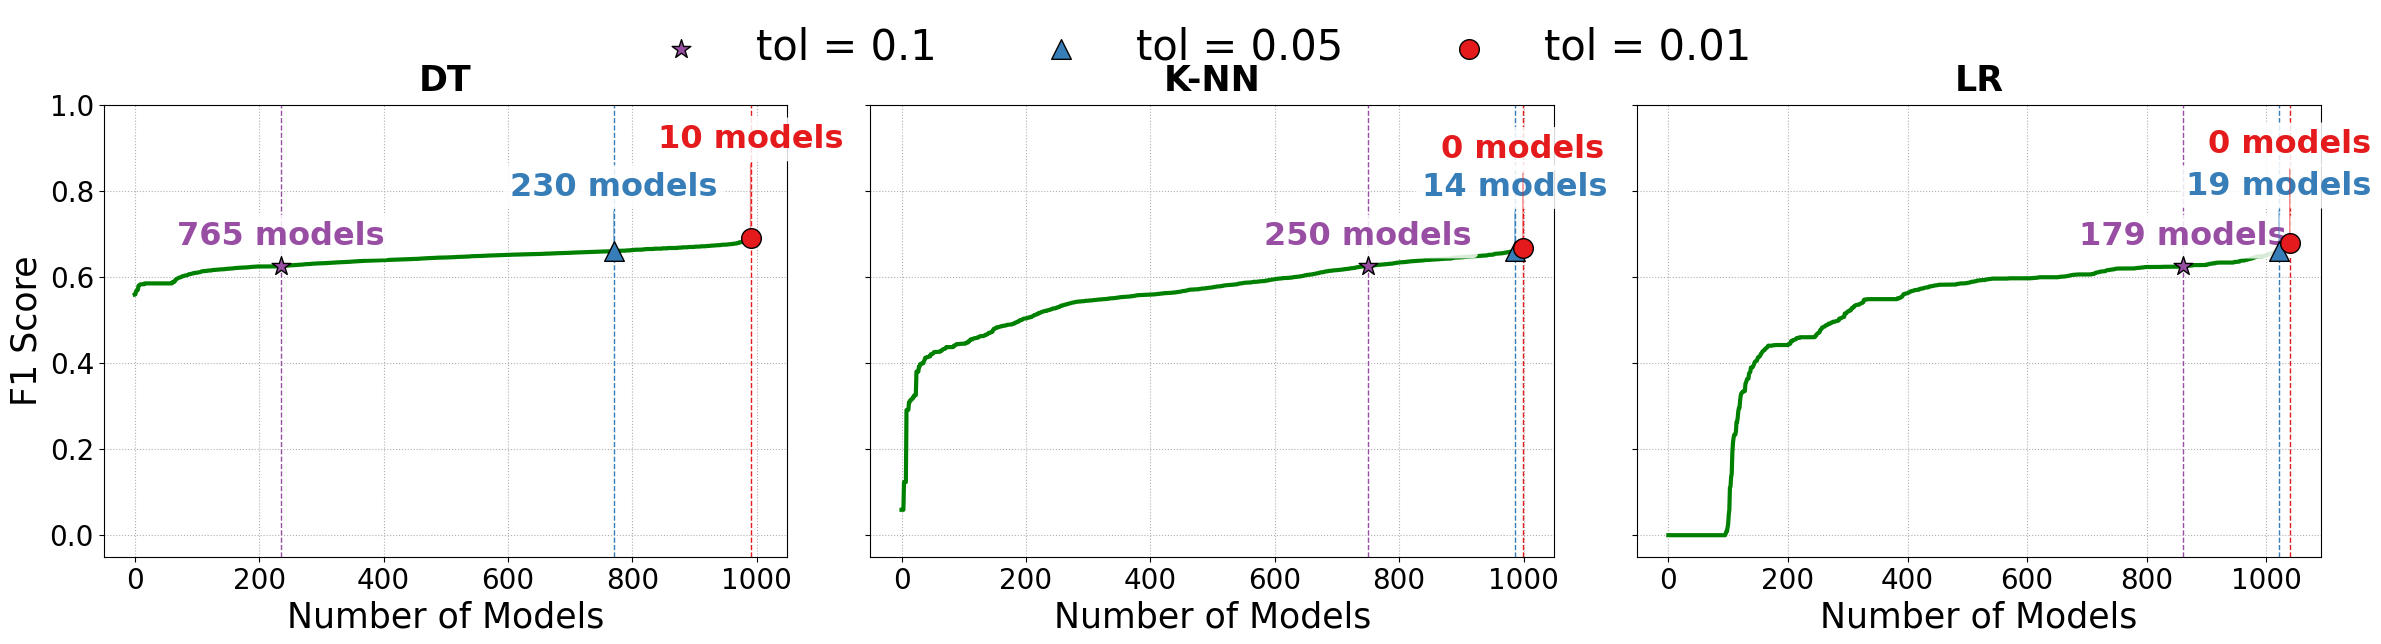

In [65]:
plot_rashomon_curve(all_data, print_xlab=True,
                         save = False, file_path = '/home/forru/Results/compass/plots', filename = 'Rashomon Curves')

In [66]:
epsilon = 0.05
base_thr = baselines['val_f1'].mean()
threshold = base_thr - (epsilon*base_thr)
cond = f'val_f1 >= {threshold}'

#rashomon set definition
rtc_rash_set, rtc_rash_df = get_rashomon(rtc_df, cond)
knn_rash_set, knn_rash_df = get_rashomon(knn_df, cond)
lr_rash_set, lr_rash_df = get_rashomon(lr_df, cond)
rash_set, rash_df = get_rashomon(df, cond)

rtc_rash_pca = rtc_pca[rtc_pca['model_id'].isin(rtc_rash_set)] 
knn_rash_pca = knn_pca[knn_pca['model_id'].isin(knn_rash_set)] 
lr_rash_pca = lr_pca[lr_pca['model_id'].isin(lr_rash_set)]
rash_pca = df_pca[df_pca['model_id'].isin(rash_set)]

dataframes = [rtc_pca, knn_pca, lr_pca, df_pca]
rash = [rtc_rash_set, knn_rash_set, lr_rash_set, rash_set]

#for d, r in zip(dataframes, rash):
    #d['is_rashomon'] = d['model_id'].isin(r).astype(int)

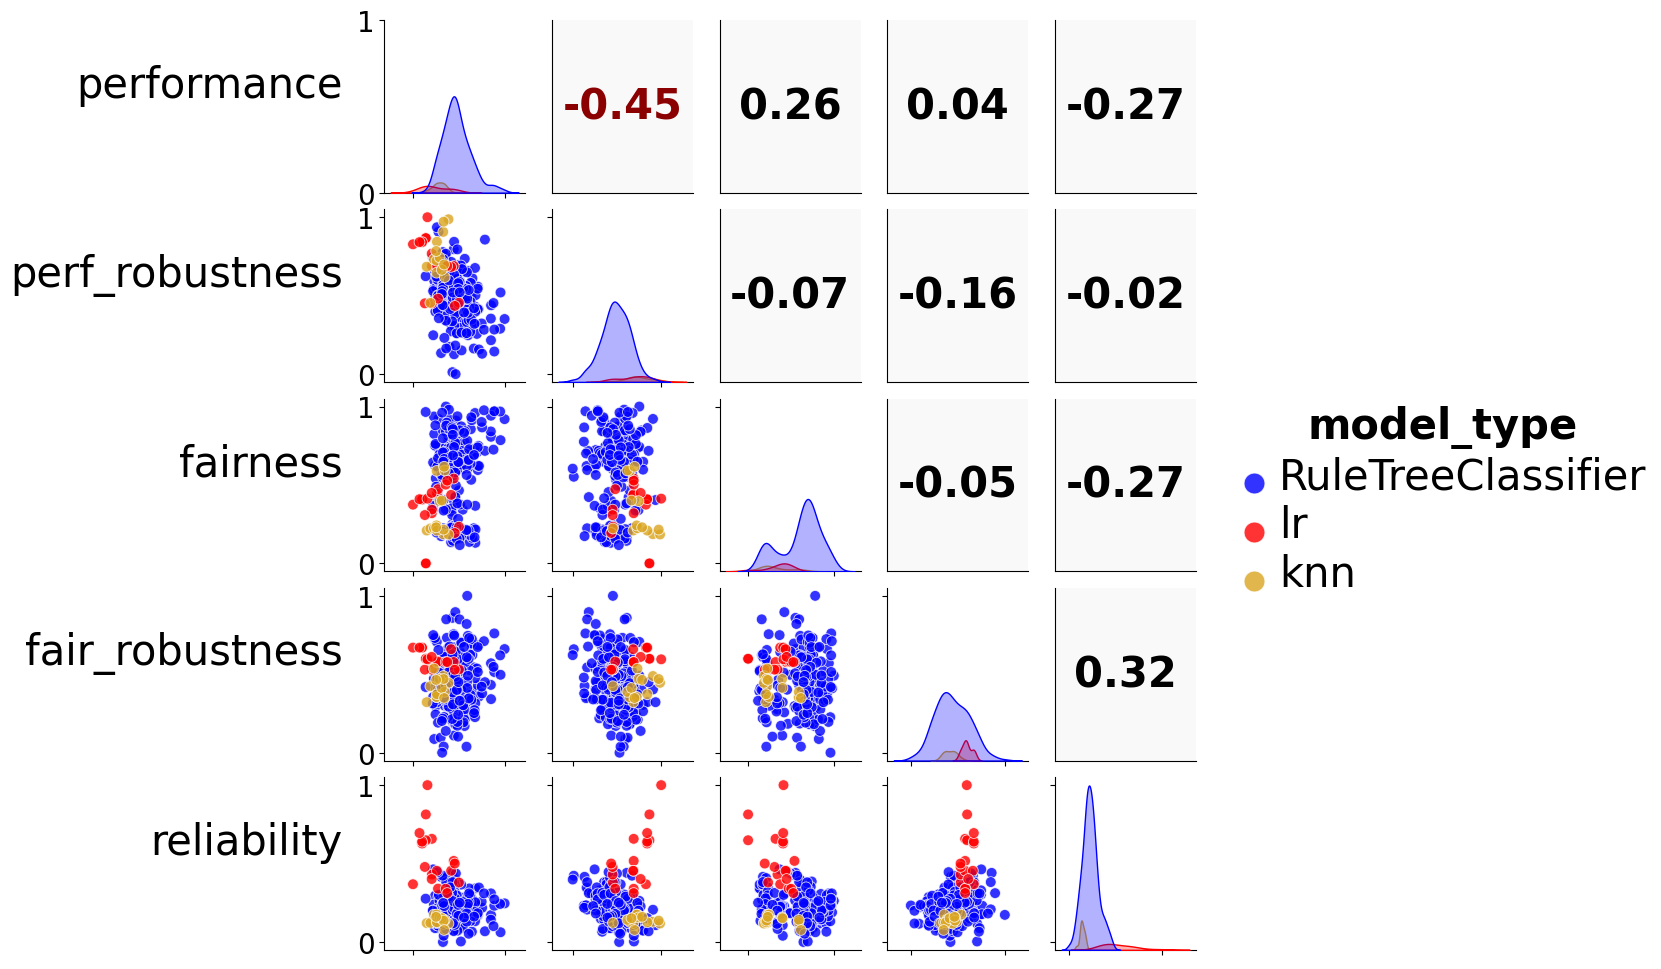

In [67]:
metrics_to_plot = ['performance', 'perf_robustness', 'fairness', 'fair_robustness', 'reliability']

order = ['RuleTreeClassifier', 'lr', 'knn']
rash_pca_new = rash_pca.copy()
rash_pca_new['model_type'] = pd.Categorical(rash_pca_new['model_type'], categories=order, ordered=True)
rash_pca_new = rash_pca_new.sort_values('model_type')

plot_relations(rash_pca_new, metrics_to_plot, save = False, labelsize = 30,
               legendsize = 15, alpha = 0.8, figsize = (10,10), show_xlab=False,
               file_path = '/home/forru/Results/compass/plots', figname = 'Family Shares on RS', zoom_on_rs = True)

## Equivalence Study for the RS

### Distance matrices computation

In [68]:
df_path = '/home/forru/Split_salvati/compass'
model_path = '/home/forru/Models/compass'
file_path = '/home/forru/Results/compass'
X_val_df = pd.read_csv(f'{df_path}/compass_X_val.csv')
X_val = np.genfromtxt(f'{df_path}/compass_X_val.csv', delimiter=',', skip_header=1)
y_val = np.genfromtxt(f'{df_path}/compass_y_val.csv', delimiter=',', skip_header=1)
cols = ['performance', 'fairness', 'fair_robustness', 'perf_robustness', 'reliability']

**HEAVY CODE TO SAVE SHAPS AND MATRICES**      
rash_ids = rash_pca['model_id'].values
rash_models_dict = load_models(model_ids = rash_ids, path = model_path)

#shaps = fi.get_tot_shaps(rash_models_dict, X_val, y_val, n_jobs = -1, save = True, file_path = file_path, file_name = 'rash_shaps')
#preds = compute_preds_probs_dict(rash_models_dict, X_val, save = True, file_path = file_path, file_name = 'rash_preds')
#probs = compute_preds_probs_dict(rash_models_dict, X_val, save = True, file_path = file_path, file_name = 'rash_probs', probs = True)

shap_matrix = eqv.get_dist_matrix_from_arrays(
    arrays_dict = rash_shaps, function = fi.importance_array_similarity, X_ts = X_val, y_true = y_val,
    metric_name = 'feat_importance_dist(spearman_error)', dist = 'spearman_error', save = False, file_path = file_path, file_name = 'rash_shap_matrix')

preds_matrix = eqv.get_dist_matrix_from_arrays(
    arrays_dict = rash_preds, function = pf.predictions_similarity, X_ts = X_val, y_true = y_val,
    metric_name = 'preds_dist(hamming_loss)', dist = hamming_loss, save = False, file_path = file_path, file_name = 'rash_preds_matrix')


In [69]:
rash_shaps = load(os.path.join(file_path, 'rash_shaps.joblib'))
rash_preds = load(os.path.join(file_path, 'rash_preds.joblib'))
shap_matrix = pd.read_pickle(f'{file_path}/rash_shap_matrix.pkl')
preds_matrix = pd.read_pickle(f'{file_path}/rash_preds_matrix.pkl')

other_matrices = eqv.get_dist_matrices_from_df(rash_pca, cols, dist_metric = 'cityblock')
rash_dist_matrices = other_matrices | shap_matrix | preds_matrix
rash_scaled_dist_matrices = eqv.scale_matrices(rash_dist_matrices)

In [70]:
rash_dm = rash_dist_matrices
scaled_rash_dm = rash_scaled_dist_matrices
d = 'compass'

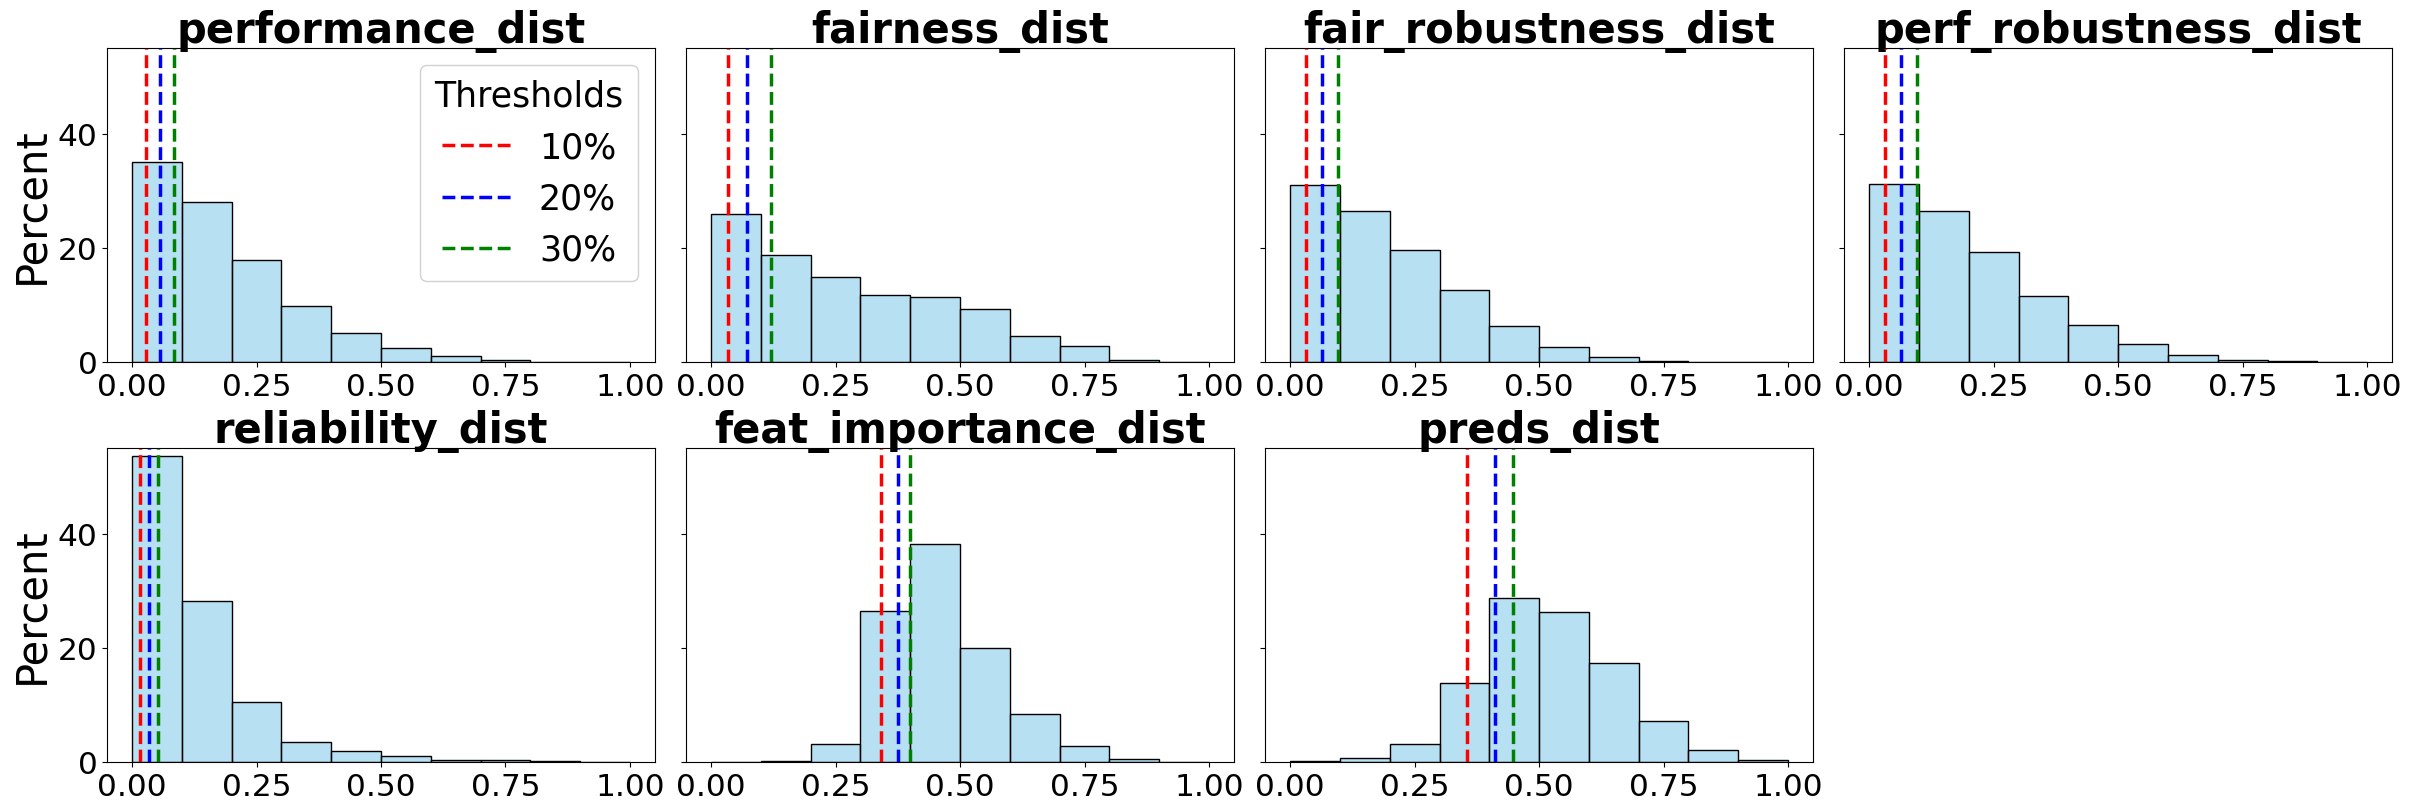

In [72]:
percs = [10,20,30]

mapping = {
    'performance_dist(cityblock)': 'performance_dist',
    'fairness_dist(cityblock)': 'fairness_dist',
    'fair_robustness_dist(cityblock)': 'fair_robustness_dist',
    'perf_robustness_dist(cityblock)': 'perf_robustness_dist',
    'reliability_dist(cityblock)': 'reliability_dist',
    'feat_importance_dist(spearman_error)': 'feat_importance_dist',
    'preds_dist(hamming_loss)': 'preds_dist'    
}

scaled_rash_dm2 = {mapping.get(k, k): v for k, v in scaled_rash_dm.items()}
#------------------------------------------------------------------


eqv.plot_dist_matrices_distributions(scaled_rash_dm2, ylim_max = 55, bins = 10,percentiles = percs, cols = 4, save = False,
                                 figsize=(24,8), file_path = f'/home/forru/Results/{d}/plots',
                                 filename = f'Distance Matrices Distributions',
                                 labelsize = 30)

### Inter-family Analysis

In [73]:
cols_to_keep_ts = [col for col in full_df.columns if col.startswith('test_') or col in ['model_id', 'model_type', 'n_neighbors']]
df_ts = preprocess_data(full_df[cols_to_keep_ts], prefix = 'test')

df_pca_ts = get_pca_metrics(df_ts, prefix = 'test').drop('model_type', axis=1)


LABEL COUNTS: 
207    3
88     3
115    3
192    3
100    3
22     2
67     2
146    2
52     2
27     2
33     2
215    2
85     2
138    2
50     2
141    2
117    2
110    2
105    2
114    2
65     2
29     2
25     2
91     2
170    2
31     2
221    2
208    2
202    2
219    2
28     2
12     2
Name: count, dtype: int64
MEC: 32 Silhouette: 0.20912547528517111


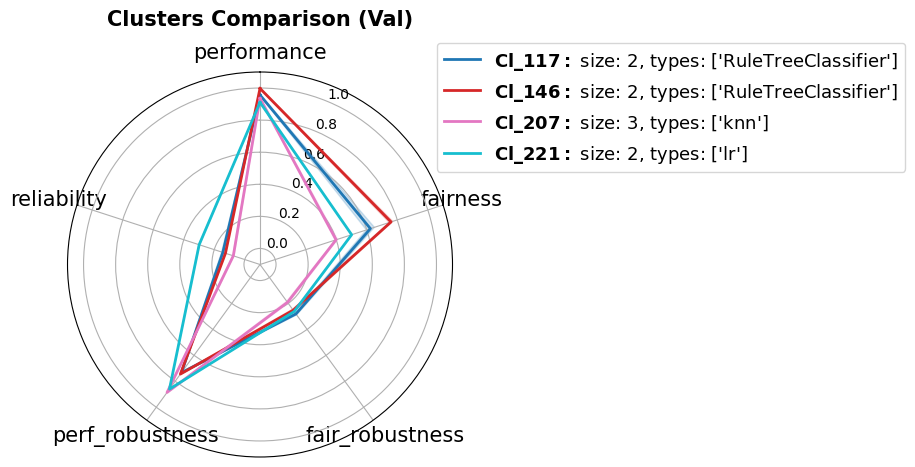

In [74]:
cut_level_dendro = 0
rash = rash_pca
data = df_pca
metrics_to_plot = ['performance', 'fairness', 'fair_robustness', 'perf_robustness', 'reliability']
perc = 30
#-----------------------------------------------------------

neg_consensus_matrix = eqv.get_consensus_matrix(rash_dm, perc = perc)
dct = eqv.get_cluster_info(neg_consensus_matrix, cut_level = cut_level_dendro, min_cluster_size = 2)
clustering = dct['clustering']
labels = dct['labels']
label_counts = dct['label_counts']
mec = dct['max_equiv_clusters']
silhouette = dct['silhouette']
print(f'MEC: {mec} Silhouette: {silhouette}')

metrics_per_cluster = eqv.get_cluster_metrics_df(rash, labels, min_cluster_counts = 2)
d1 = metrics_per_cluster[['model_id','model_type','cluster']]
metrics_per_cluster_ts = pd.merge(d1, df_pca_ts, on='model_id')

val_clusters_7 = [146,117,207,221]
val_clusters_6 = [105,108,93,151,163]
val_clusters_5 = [76,78,67,107,115]
val_clusters_4 = [47,51,43,78]
val_clusters_3 = [32,35,26,22,54]
val_clusters_2 = [22,19,35]
val_clusters_1 = [10,11,14,16,17]

eqv.plot_clusters(metrics_per_cluster, data, metrics_to_plot, label_counts, valuable_clusters = val_clusters_7, save = False, show_legend = True,
              file_path = f'/home/forru/Results/{d}/plots', title = 'Clusters Comparison (Val)')


In [75]:
for m in metrics_to_plot:
    print(metrics_per_cluster.groupby('cluster')[metrics_to_plot].mean().sort_values(by = m, ascending = False).head(1))

         performance  fairness  fair_robustness  perf_robustness  reliability
cluster                                                                      
146         2.028205  2.937592        -0.435475        -1.294511    -1.156897
         performance  fairness  fair_robustness  perf_robustness  reliability
cluster                                                                      
146         2.028205  2.937592        -0.435475        -1.294511    -1.156897
         performance  fairness  fair_robustness  perf_robustness  reliability
cluster                                                                      
117         1.620573  1.155323        -0.166624        -1.510288    -1.056173
         performance  fairness  fair_robustness  perf_robustness  reliability
cluster                                                                      
207         1.409803 -1.812571        -0.998045         1.495951    -1.461453
         performance  fairness  fair_robustness  perf_robustness

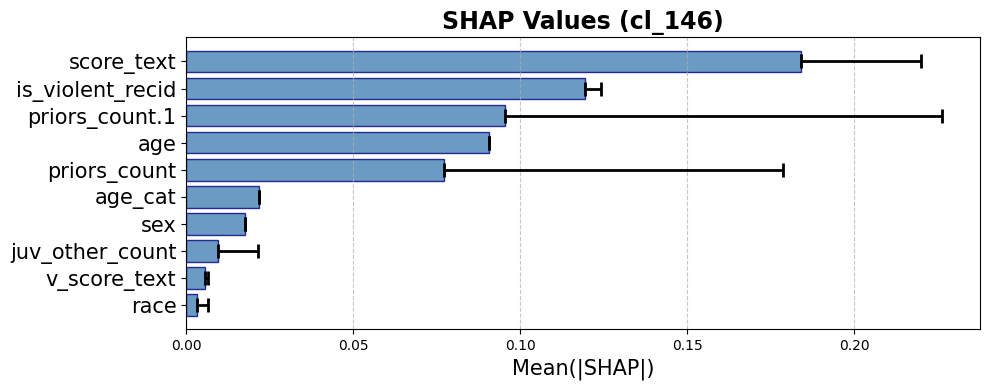

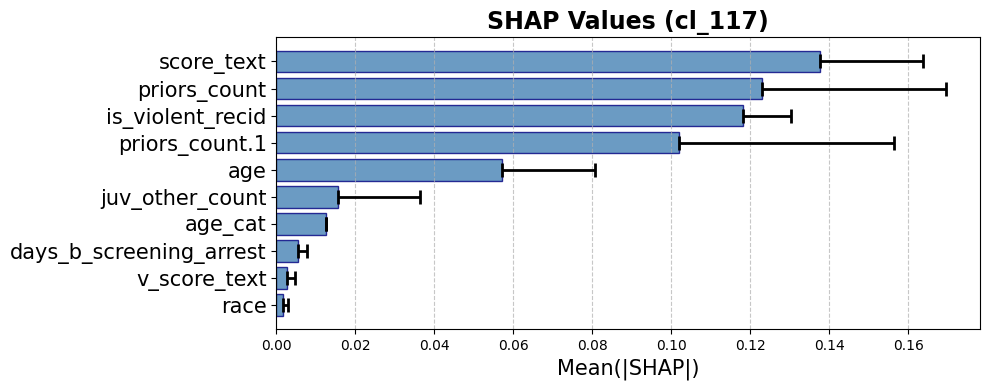

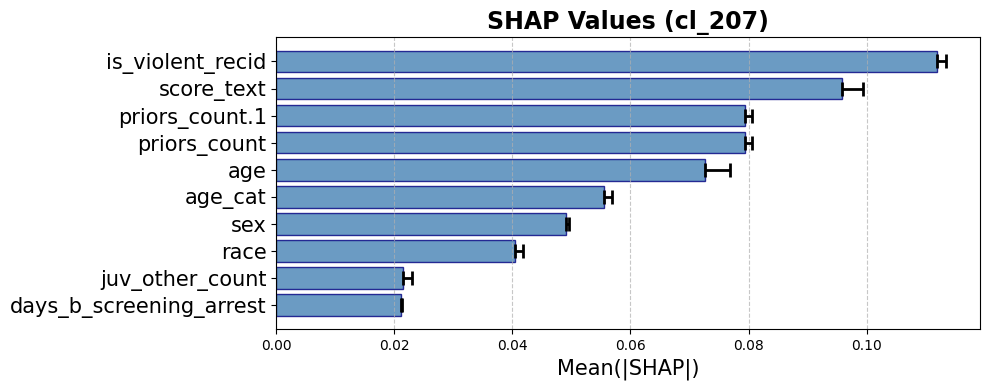

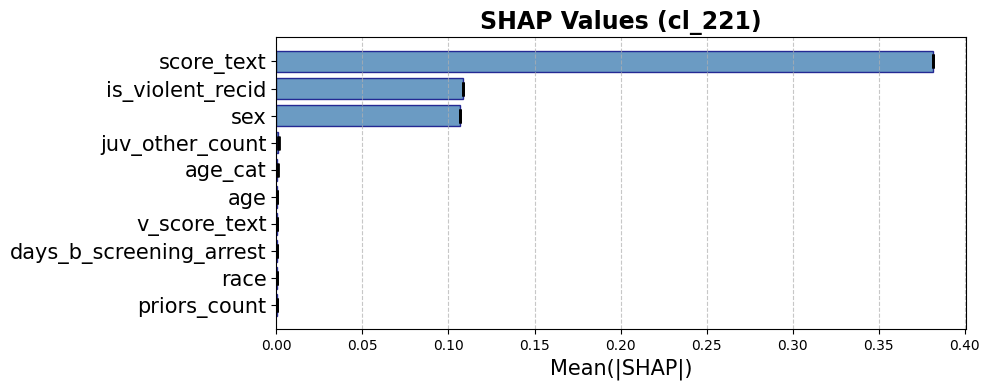

In [76]:
clusters = val_clusters_7
rash = rash_pca
#------------------------------------------------

metrics_per_cluster = eqv.get_cluster_metrics_df(rash, labels, min_cluster_counts = 2)
d1 = metrics_per_cluster[['model_id','model_type','cluster']]
metrics_per_cluster_ts = pd.merge(d1, df_pca_ts, on='model_id')

for cluster in clusters:
    ids = metrics_per_cluster['model_id'][metrics_per_cluster['cluster'] == cluster].values
    filtered_rash_shaps = [shap for m_id, shap in rash_shaps.items() if m_id in ids]
    
    eqv.plot_shaps(filtered_rash_shaps, X_val_df.columns, title = f'SHAP Values (cl_{cluster})', top_n = 10,
                   save = False, file_path = f'/home/forru/Results/{d}/plots')

In [77]:
path_df = f'/home/forru/Split_salvati/{d}'
path_models = f'/home/forru/Models/{d}'
name = 'compass'
X_ts = np.genfromtxt(f'{path_df}/{name}_X_ts.csv', delimiter=',', skip_header=1)
X_val = np.genfromtxt(f'{path_df}/{name}_X_val.csv', delimiter=',', skip_header=1)
    
y_ts = np.genfromtxt(f'{path_df}/{name}_y_ts.csv', delimiter=',', skip_header=1)
y_val = np.genfromtxt(f'{path_df}/{name}_y_val.csv', delimiter=',', skip_header=1)

In [78]:
clusters = val_clusters_7

#-------------------------------------------------

for cluster in clusters:
    model_ids = metrics_per_cluster['model_id'][metrics_per_cluster['cluster'] == cluster].values
    path_base = Path(path_models)
    models = []
    for m_id in model_ids:
        pattern = f"*{m_id}*.joblib"
        m = load(list(path_base.rglob(pattern))[0])
        models.append(m)

    print(f'cluster {cluster}: {eqv.rel_abs_error_cluster(models, X_val, y_val)}')

cluster 146: (0.06299376299376294, 0.018998118998119012)
cluster 117: (0.14598554598554594, 0.04599544599544603)
cluster 207: (0.10598950598950592, 0.005887257680751832)
cluster 221: (0.01599841599841601, 0.0)


In [79]:
valuable_clusters = val_clusters_7
rash = rash_preds
#----------------------------------------------------------------

filtered_mpc = metrics_per_cluster[metrics_per_cluster['cluster'].isin(valuable_clusters)]
res = eqv.mean_freq_classes_per_cluster(filtered_mpc, rash)
print(f'means:\n {res[0]}')
print(f'stdvs:\n {res[1]}')

means:
         117       146      207       221
0  0.621782  0.580693  0.60198  0.557426
1  0.378218  0.419307  0.39802  0.442574
stdvs:
         117       146       207  221
0  0.022772  0.009406  0.002915  0.0
1  0.022772  0.009406  0.002915  0.0


### Intra-family Analysis

In [80]:
cols = ['performance', 'fairness', 'fair_robustness', 'perf_robustness', 'reliability', 'complexity']
dataframes = [rtc_rash_pca, lr_rash_pca, knn_rash_pca]
#dataframes = [rtc_rash_pca, lr_rash_pca]

#ottengo gli shaps e le preds filtrate per famiglia
filtered_rs_list = []
filtered_rpr_list = []
for data in dataframes:
    filtered_rash_shaps = {m_id: shap for m_id, shap in rash_shaps.items() if m_id in data['model_id'].values}
    filtered_rash_preds = {m_id: pred for m_id, pred in rash_preds.items() if m_id in data['model_id'].values}
    filtered_rs_list.append(filtered_rash_shaps)
    filtered_rpr_list.append(filtered_rash_preds)
    
#ottengo le matrici di shaps per famiglia
shap_matrices_list = []
for rs in filtered_rs_list:
    filt_shap_matrix = eqv.get_dist_matrix_from_arrays( 
                                           arrays_dict = rs, function = fi.importance_array_similarity, 
                                           X_ts = X_val, y_true = y_val, metric_name = 'feat_importance_dist(spearman_error)', 
                                           dist = 'spearman_error', save = False)
    shap_matrices_list.append(filt_shap_matrix)

#ottengo le matrici di preds per famiglia
preds_matrices_list = []
for rpr in filtered_rpr_list:
    filt_preds_matrix = eqv.get_dist_matrix_from_arrays( 
                                           arrays_dict = rpr, function = pf.predictions_similarity, X_ts = X_val, y_true = y_val,
                                           metric_name = 'preds_dist(hamming_loss)', dist = hamming_loss, save = False)
    preds_matrices_list.append(filt_preds_matrix)

#ottengo le matrici di distanza scalate e non, per ogni famiglia
filt_rdm_list = []
for i, data in enumerate(dataframes):
    filt_other_matrices = eqv.get_dist_matrices_from_df(data, cols, dist_metric = 'cityblock')
    filt_rash_dist_matrices = filt_other_matrices | shap_matrices_list[i] | preds_matrices_list[i]
    filt_rash_scaled_dist_matrices = eqv.scale_matrices(filt_rash_dist_matrices)
    filt_rdm_list.append((filt_rash_dist_matrices, filt_rash_scaled_dist_matrices))


#vediamo se torna tutto
rtc_rash_preds, lr_rash_preds, knn_rash_preds = filtered_rpr_list[0], filtered_rpr_list[1], filtered_rpr_list[2]
#rtc_rash_preds, lr_rash_preds = filtered_rpr_list[0], filtered_rpr_list[1]

rtc_shap_matrix, lr_shap_matrix, knn_shap_matrix = shap_matrices_list[0], shap_matrices_list[1], shap_matrices_list[2]
rtc_preds_matrix, lr_preds_matrix, knn_preds_matrix = preds_matrices_list[0], preds_matrices_list[1], preds_matrices_list[2]
#rtc_shap_matrix, lr_shap_matrix= shap_matrices_list[0], shap_matrices_list[1]
#rtc_preds_matrix, lr_preds_matrix = preds_matrices_list[0], preds_matrices_list[1]

rtc_rash_dist_matrices, rtc_rash_scaled_dist_matrices = filt_rdm_list[0]
lr_rash_dist_matrices, lr_rash_scaled_dist_matrices = filt_rdm_list[1]
knn_rash_dist_matrices, knn_rash_scaled_dist_matrices = filt_rdm_list[2]

assert rtc_shap_matrix['feat_importance_dist(spearman_error)'].shape[0] == rtc_rash_pca.shape[0]
assert lr_shap_matrix['feat_importance_dist(spearman_error)'].shape[0] == lr_rash_pca.shape[0]
assert lr_preds_matrix['preds_dist(hamming_loss)'].shape[0] == lr_rash_pca.shape[0]
assert rtc_preds_matrix['preds_dist(hamming_loss)'].shape[0] == rtc_rash_pca.shape[0]
assert len(lr_rash_dist_matrices['performance_dist(cityblock)']) == lr_rash_pca.shape[0]
assert len(rtc_rash_dist_matrices['performance_dist(cityblock)']) == rtc_rash_pca.shape[0]

In [81]:
fam = 'rtc'
d = 'compass'
rash_dm = rtc_rash_dist_matrices
scaled_rash_dm = rtc_rash_scaled_dist_matrices

LABEL COUNTS: 
92     3
121    2
8      2
113    2
71     2
114    2
196    2
52     2
62     2
173    2
107    2
108    2
202    2
99     2
127    2
51     2
74     2
Name: count, dtype: int64


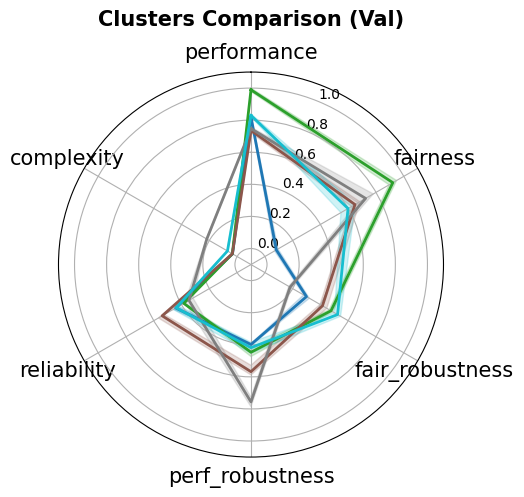

In [82]:
cut_level_dendro = 0
rash = rtc_rash_pca
data = rtc_pca
metrics_to_plot = ['performance', 'fairness', 'fair_robustness', 'perf_robustness', 'reliability', 'complexity']
#-----------------------------------------------------------

neg_consensus_matrix = eqv.get_consensus_matrix(rash_dm, perc = perc)
dct = eqv.get_cluster_info(neg_consensus_matrix, cut_level = cut_level_dendro, min_cluster_size = 2)
clustering = dct['clustering']
labels = dct['labels']
label_counts = dct['label_counts']

metrics_per_cluster = eqv.get_cluster_metrics_df(rash, labels, min_cluster_counts = 2)
d1 = metrics_per_cluster[['model_id','model_type','cluster']]
metrics_per_cluster_ts = pd.merge(d1, df_pca_ts, on='model_id')

val_clusters_8 = [74,121,99,92,62]
val_clusters_7 = [53,56,93,75,59,63]
val_clusters_6 = [41,43,54,95,47]
val_clusters_5 = [72,31,39,70,33]
val_clusters_4 = [51,22,27,56,23]
val_clusters_3 = [31,26,17,35,14]
val_clusters_2 = [8,18,10,11]
val_clusters_1 = [9,1,5,6]

eqv.plot_clusters(metrics_per_cluster, data, metrics_to_plot, label_counts, valuable_clusters = val_clusters_8, save = False, show_legend = False,
              file_path = f'/home/forru/Results/{d}/plots/{fam}', title = 'Clusters Comparison (Val)')

In [83]:
for m in metrics_to_plot:
    if m == 'complexity':
        print(metrics_per_cluster.groupby('cluster')[metrics_to_plot].mean().sort_values(by = m, ascending = True).head(1))
    else:
        print(metrics_per_cluster.groupby('cluster')[metrics_to_plot].mean().sort_values(by = m, ascending = False).head(1))

         performance  fairness  fair_robustness  perf_robustness  reliability  \
cluster                                                                         
74          2.028205  2.937592        -0.435475        -1.294511    -1.156897   

         complexity  
cluster              
74        -1.511249  
         performance  fairness  fair_robustness  perf_robustness  reliability  \
cluster                                                                         
74          2.028205  2.937592        -0.435475        -1.294511    -1.156897   

         complexity  
cluster              
74        -1.511249  
         performance  fairness  fair_robustness  perf_robustness  reliability  \
cluster                                                                         
121         1.676453  1.099851        -0.203542        -1.440736    -1.049746   

         complexity  
cluster              
121       -1.237887  
         performance  fairness  fair_robustness  perf_robustness  reli

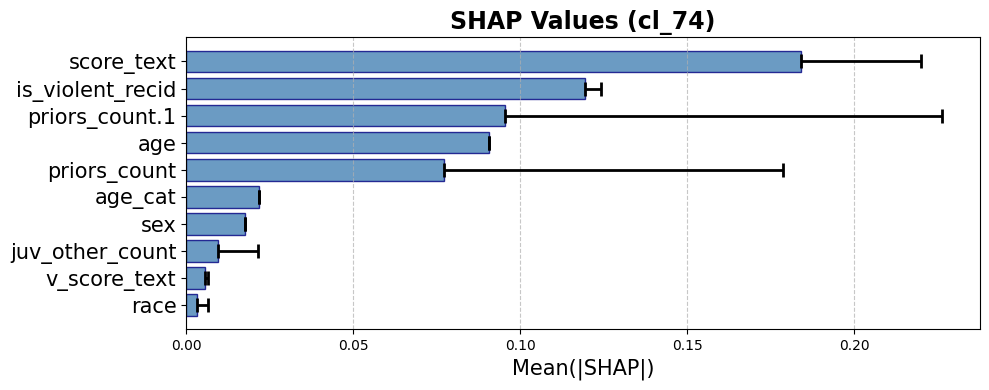

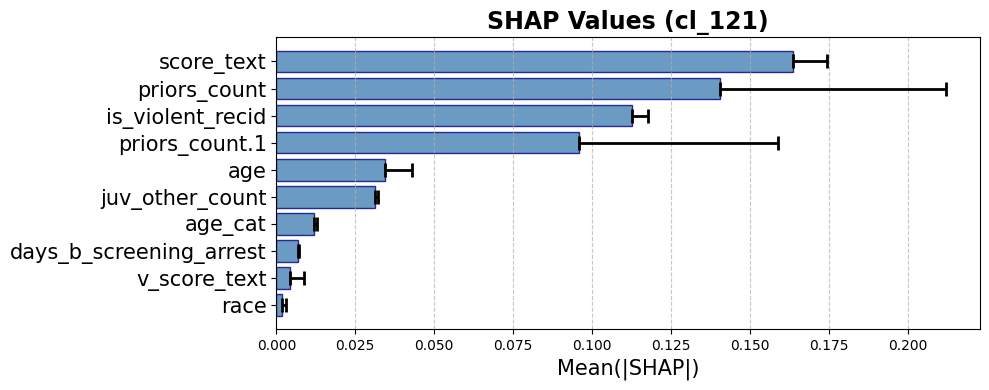

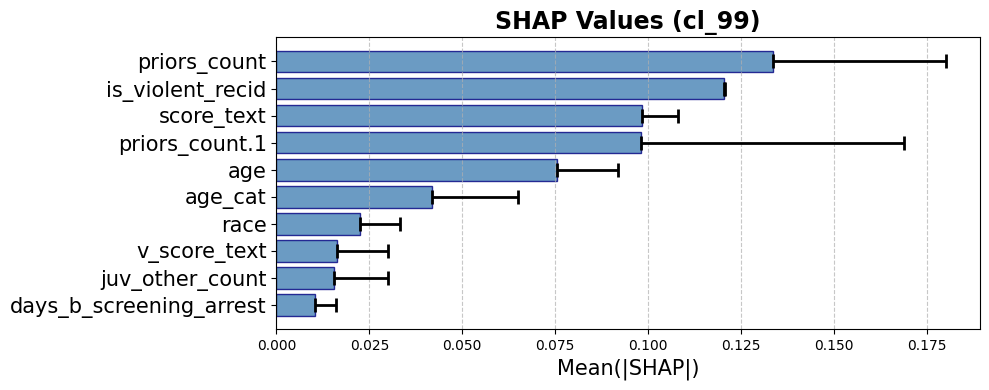

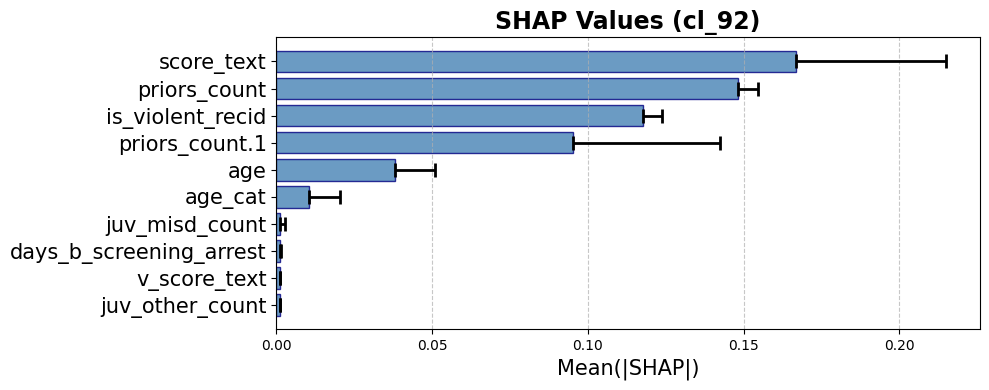

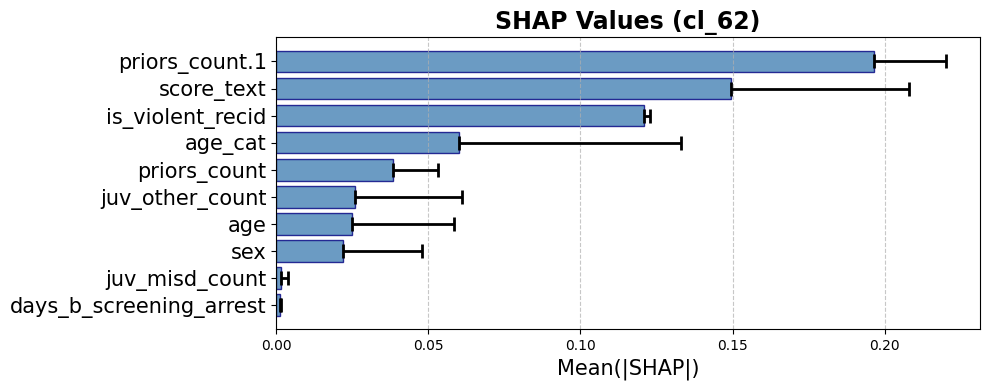

In [84]:
clusters = val_clusters_8
rash = rtc_rash_pca
#------------------------------------------------

for cluster in clusters:
    metrics_per_cluster = eqv.get_cluster_metrics_df(rash, labels, min_cluster_counts = 2)
    ids = metrics_per_cluster['model_id'][metrics_per_cluster['cluster'] == cluster].values
    filtered_rash_shaps = [shap for m_id, shap in rash_shaps.items() if m_id in ids]
    
    eqv.plot_shaps(filtered_rash_shaps, X_val_df.columns, title = f'SHAP Values (cl_{cluster})', top_n = 10,
                   save = True, file_path = f'/home/forru/Results/{d}/plots/{fam}')